In [1]:
from pathlib import Path
from LHC_FillingPattern import LHCFillingPattern 
import matplotlib.pyplot as plt
import numpy as np
import dask.dataframe as dd
import pathlib
import pandas as pd
from pprint import pprint
import math
import pyarrow.dataset as ds
from scipy.stats import linregress
from lmfit import Model 
import warnings
from matplotlib.dates import DateFormatter
from typing import Optional

In [2]:
# user settings
beam = "B1"
ip   = "1"
PLANE_DEFAULT = 'H'   
RAWDATA = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/rawdata')
FILLINFO       = Path("/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/fills-info")
fbmodes        = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
fbmodes[(fbmodes.BMODE == "STABLE") & (fbmodes.duration > 5*3600*1.0e9)].head()
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709]) 

In [3]:
fbmodes[(fbmodes.BMODE == "STABLE")].head()

,BMODE,tsStart,tsEnd,QFLAG,duration,duration [m],duration [h],HX:AMODE,injection_scheme
FILLNO,,,,,,,,,
10489,STABLE,1745305756726488525,1745306445773738525,STABLE,689047250000,11.484121,0.191402,9.0,Single_12b_8_8_8_1bpi_12inj
10491,STABLE,1745308696263613525,1745326091176238525,STABLE,17394912625000,289.915210,4.831920,9.0,Single_12b_8_8_8_1bpi_12inj
10530,STABLE,1745692769664238525,1745701404414363525,STABLE,8634750125000,143.912502,2.398542,9.0,Single_12b_8_8_8_1bpi_12inj
10589,STABLE,1746445729803613525,1746449925971738525,STABLE,4196168125000,69.936135,1.165602,9.0,Single_4b_2_2_2_noLRs
10590,STABLE,1746456976242238525,1746489950314613525,STABLE,32974072375000,549.567873,9.159465,9.0,Single_12b_8_8_8_1bpi_12inj


In [3]:
# ------------------------------------------------------------------
# Build Families for ONE fill
# ------------------------------------------------------------------
def build_families_for_fill(
    fillno: int,
    beam: str,
    ip: str,
    RAWDATA: Path,
    long_gap_set=(32, 63),
    small_gap=8,
    F4_offset_after_long=6,    # 7th bunch (bid_first + 6)
    # F5_offset_after_long removed from use; Family_5 now from small-gap trains
    F6_offset_before_small=26, # 27th bunch (bid_first + 26)
    enforce_filled=True,
    intensity_threshold=None,
) -> dict:
    # --- Fetch filling pattern object ---
    fpat = LHCFillingPattern(fillno, RAWDATA)

    # beam-specific train table & "filled" mask
    if beam.upper() == "B1":
        trains = fpat.bunchtrainsDF_b1.copy()
        filled_slots = fpat.bunches_b1
    else:
        trains = fpat.bunchtrainsDF_b2.copy()
        filled_slots = fpat.bunches_b2

    trains = (
        trains.loc[trains["id"] != 0]
              .sort_values("bid_first")
              .reset_index(drop=True)
    )

    orbit_len = 3564

    # --- optional BUNCH_INTENSITY for filtering ---
    if intensity_threshold is not None:
        int_var = f"LHC.BCTFR.B6R4.{beam}:BUNCH_INTENSITY"
        ser_int = load_series(int_var, RAWDATA, fillno=fillno)  # helper below
        if ser_int.empty:
            arr_intensity = np.zeros(orbit_len, dtype=float)
        else:
            last_vals = np.asarray(ser_int.iloc[-1])
            if last_vals.shape[0] != orbit_len:
                tmp = np.zeros(orbit_len, dtype=float)
                n = min(orbit_len, last_vals.shape[0])
                tmp[:n] = last_vals[:n]
                last_vals = tmp
            arr_intensity = last_vals
    else:
        arr_intensity = None

    # ---- filter helpers ------------------------------------------------
    filled_mask = np.zeros(orbit_len, dtype=bool)
    filled_mask[filled_slots] = True

    def _filter(arr: np.ndarray) -> np.ndarray:
        if arr.size == 0:
            return arr
        arr = arr.astype(int)
        if enforce_filled:
            arr = arr[filled_mask[arr]]
        if arr_intensity is not None and intensity_threshold is not None:
            arr = arr[arr_intensity[arr] >= intensity_threshold]
        return arr

    # ------------------------------------------------------------------
    # Family_1: first bunch of trains whose *preceding* gap is long (32 or 63)
    # ------------------------------------------------------------------
    mask_long = trains["gap"].isin(long_gap_set)
    Family_1 = trains.loc[mask_long, "bid_first"].to_numpy(int)

    # ------------------------------------------------------------------
    # Family_2: last bunch of a train that is followed by a long (≥31) gap
    # ------------------------------------------------------------------
    next_start = trains["bid_first"].shift(-1).fillna(orbit_len).astype(int)
    trains["gap_after"] = next_start - trains["bid_last"] - 1
    mask_big_gap = trains["gap_after"] >= 31
    Family_2 = trains.loc[mask_big_gap, "bid_last"].to_numpy(int)

    # ------------------------------------------------------------------
    # Family_3: first slot of max LR encounter per train
    # ------------------------------------------------------------------
    lr = fpat.lrencounters[beam][f"ip{ip}"]  # length-3564 array
    peak_slots = []
    for _, row in trains.iterrows():
        bids = np.asarray(row["bids"], dtype=int)
        lr_train = lr[bids]
        max_val = lr_train.max()
        first_idx = np.where(lr_train == max_val)[0][0]
        peak_slots.append(bids[first_idx])
    Family_3 = np.asarray(peak_slots, dtype=int)

    # ------------------------------------------------------------------
    # Family_4: 7th bunch in long-gap trains (bid_first + 6)
    # ------------------------------------------------------------------
    Family_4 = (trains.loc[mask_long, "bid_first"] + F4_offset_after_long).to_numpy(int)

    # ------------------------------------------------------------------
    # Family_5 (MODIFIED): 15th bunch in trains whose *preceding* gap == small_gap
    #                      (e.g., gap == 8). Require nbunches >= 15.
    # ------------------------------------------------------------------
    mask_gap_small_15 = (trains["gap"] == small_gap) & (trains["nbunches"] >= 15)
    cand_F5 = (trains.loc[mask_gap_small_15, "bid_first"] + 14).to_numpy(int)
    # clip to each selected train's end (safety)
    last_F5 = trains.loc[mask_gap_small_15, "bid_last"].to_numpy(int)
    Family_5 = cand_F5[cand_F5 <= last_F5]

    # ------------------------------------------------------------------
    # Family_6: 27th bunch IN THE TRAIN *BEFORE* a gap==8 train
    # ------------------------------------------------------------------
    rows_gap8 = trains["gap"] == small_gap
    train_before_gap8 = trains.shift(1).loc[rows_gap8].dropna()
    mask_nbunch27 = train_before_gap8["nbunches"] >= (F6_offset_before_small + 1)
    Family_6 = (train_before_gap8.loc[mask_nbunch27, "bid_first"] + F6_offset_before_small).to_numpy(int)

    # ------------------------------------------------------------------
    # Family_7: first bunch AFTER an 8-slot gap (the gap8 train itself)
    # ------------------------------------------------------------------
    Family_7 = trains.loc[rows_gap8, "bid_first"].to_numpy(int)

    # ------------------------------------------------------------------
    # Family_8: last bunch BEFORE each gap8 (the last bunch of the previous train)
    # ------------------------------------------------------------------
    train_before_gap8_full = trains.shift(1).loc[rows_gap8].dropna()
    Family_8 = train_before_gap8_full["bid_last"].astype(int).to_numpy()

    # ------------------------------------------------------------------
    # apply filters
    # ------------------------------------------------------------------
    fam_dict = {
        "Family_1": _filter(Family_1),
        "Family_2": _filter(Family_2),
        "Family_3": _filter(Family_3),
        "Family_4": _filter(Family_4),
        "Family_5": _filter(Family_5),
        "Family_6": _filter(Family_6),
        "Family_7": _filter(Family_7),
        "Family_8": _filter(Family_8),
    }

    # report
    #print(f"\n=== Families for fill {fillno} ({beam}, {ip}) ===")
    ##for k, v in fam_dict.items():
        #print(f"{k}: n={len(v)}  slots={v}")

    return fam_dict


# ------------------------------------------------------------------
# Minimal load_series helper (same as in larger module)
# ------------------------------------------------------------------
def load_series(var: str, RAWDATA: Path, fillno: int) -> pd.Series:
    root = RAWDATA / f"HX:FILLN={fillno}"
    parts = []
    for pq in root.rglob("*.parquet"):
        try:
            df = pd.read_parquet(pq, columns=[var])
        except Exception:
            continue
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")
        ser = pd.Series(df[var].to_numpy(), index=idx, name=var)
        parts.append(ser.dropna())
    if not parts:
        return pd.Series(dtype=float, name=var)
    return pd.concat(parts).sort_index()


In [5]:
fams_by_fill = {}
records = []   # for long DataFrame

for fillno in fills:
    fams = build_families_for_fill(
        fillno=fillno,
        beam=beam,
        ip=ip,
        RAWDATA=RAWDATA,
        # (optionally pass thresholds/offset overrides if needed)
    )
    fams_by_fill[fillno] = fams
# ------------------------------------------------------------------
# group back by fill -> dict, then assemble as columns
wide_rows = []
for fillno, fams in fams_by_fill.items():
    row = {"fill": fillno}
    for fam_name, slots in fams.items():
        row[fam_name] = np.array(slots, dtype=int)  # ragged arrays stored as objects
    wide_rows.append(row)

df_families_wide = pd.DataFrame(wide_rows)
print("df_families_wide shape:", df_families_wide.shape)
display(df_families_wide)

df_families_wide shape: (14, 9)


,fill,Family_1,Family_2,Family_3,Family_4,Family_5,Family_6,Family_7,Family_8
0,10665,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
1,10666,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
2,10671,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
3,10673,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
4,10675,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
5,10676,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
6,10685,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
7,10689,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
8,10690,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
9,10701,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 1

In [6]:
def _ip_collision_sets_for_fill(fillno: int, beam: str, RAWDATA: Path):
    fpat = LHCFillingPattern(fillno, RAWDATA)

    if beam.upper() == "B1":
        ip15 = np.asarray(fpat.collbid_ip15["B1"], dtype=int)
        ip2  = np.asarray(fpat.collbid_ip2 ["B1"], dtype=int)
        ip8  = np.asarray(fpat.collbid_ip8 ["B1"], dtype=int)
    else:
        ip15 = np.asarray(fpat.collbid_ip15["B2"], dtype=int)
        ip2  = np.asarray(fpat.collbid_ip2 ["B2"], dtype=int)
        ip8  = np.asarray(fpat.collbid_ip8 ["B2"], dtype=int)

    return {
        "15": set(ip15),
        "2":  set(ip2),
        "8":  set(ip8),
    }

# Classify a numpy array of slots into exclusive IP groups

def _classify_slots_by_ip(slots: np.ndarray, set15, set2, set8):
    """
    Given 1D int array `slots` and three sets (IP15, IP2, IP8),
    return dict {ip_group_label: np.ndarray([...])}.
    """
    slots = np.asarray(slots, dtype=int)

    # for each slot, boolean membership
    in15 = np.array([s in set15 for s in slots], dtype=bool)
    in2  = np.array([s in set2  for s in slots], dtype=bool)
    in8  = np.array([s in set8  for s in slots], dtype=bool)

    # masks
    m15_only   =  in15 & ~in2 & ~in8
    m2_only    = ~in15 &  in2 & ~in8
    m8_only    = ~in15 & ~in2 &  in8

    m15_2      =  in15 &  in2 & ~in8
    m15_8      =  in15 & ~in2 &  in8
    m2_8       = ~in15 &  in2 &  in8

    m15_2_8    =  in15 &  in2 &  in8

    # any that did not match any of above (should be none or "non colliding")
    mnone      = ~(m15_only | m2_only | m8_only | m15_2 | m15_8 | m2_8 | m15_2_8)

    return {
        "15_only":   slots[m15_only],
        "2_only":    slots[m2_only],
        "8_only":    slots[m8_only],
        "15_2":      slots[m15_2],
        "15_8":      slots[m15_8],
        "2_8":       slots[m2_8],
        "15_2_8":    slots[m15_2_8],
        "none":      slots[mnone],
    }

# Main: explode fams_by_fill into IP-partitioned long & summary DFs
def build_family_ip_partitions(
    fams_by_fill: dict,
    RAWDATA: Path,
    beam: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parameters
    ----------
    fams_by_fill : dict
        {fill: {"Family_1": array([...]), ...}}
    RAWDATA : Path
        root rawdata path
    beam : str
        'B1' or 'B2'

    Returns
    -------
    df_families_ip_long : DataFrame
        columns: fill, family, ip_group, slot
    df_families_ip_summary : DataFrame
        columns: fill, family, 15_only, 2_only, 8_only, 15_2, 15_8, 2_8, 15_2_8, none
        counts per group.
    """
    long_records = []
    summary_records = []

    for fillno, fams in fams_by_fill.items():
        # Get IP sets for this fill
        ip_sets = _ip_collision_sets_for_fill(fillno, beam, RAWDATA)
        set15, set2, set8 = ip_sets["15"], ip_sets["2"], ip_sets["8"]

        for fam_name, slots in fams.items():
            slots = np.asarray(slots, dtype=int)

            part_dict = _classify_slots_by_ip(slots, set15, set2, set8)

            # long rows
            for ip_group, arr in part_dict.items():
                for s in arr:
                    long_records.append({
                        "fill": fillno,
                        "family": fam_name,
                        "ip_group": ip_group,
                        "slot": int(s),
                    })

            # summary counts
            rec = {
                "fill": fillno,
                "family": fam_name,
            }
            for ip_group, arr in part_dict.items():
                rec[ip_group] = int(len(arr))
            summary_records.append(rec)

    # assemble long
    if long_records:
        df_families_ip_long = (
            pd.DataFrame.from_records(long_records)
              .sort_values(["fill", "family", "ip_group", "slot"])
              .reset_index(drop=True)
        )
    else:
        df_families_ip_long = pd.DataFrame(columns=["fill", "family", "ip_group", "slot"])

    # assemble summary
    if summary_records:
        df_families_ip_summary = (
            pd.DataFrame.from_records(summary_records)
              .sort_values(["fill", "family"])
              .reset_index(drop=True)
        )
    else:
        df_families_ip_summary = pd.DataFrame(columns=["fill", "family"])

    return df_families_ip_long, df_families_ip_summary

df_families_ip_long, df_families_ip_summary = build_family_ip_partitions(
    fams_by_fill=fams_by_fill,
    RAWDATA=RAWDATA,
    beam=beam,          # same beam as used when building families
)

print("df_families_ip_long shape:", df_families_ip_long.shape)
display(df_families_ip_long.head())

print("df_families_ip_summary shape:", df_families_ip_summary.shape)
display(df_families_ip_summary.head(9))

df_families_ip_long shape: (4494, 4)


,fill,family,ip_group,slot
0,10665,Family_1,15_2_8,1843
1,10665,Family_1,15_2_8,1996
2,10665,Family_1,15_2_8,2192
3,10665,Family_1,15_2_8,2388
4,10665,Family_1,15_8,55


df_families_ip_summary shape: (112, 10)


,fill,family,15_only,2_only,8_only,15_2,15_8,2_8,15_2_8,none
0,10665,Family_1,5,0,0,0,10,0,4,0
1,10665,Family_2,0,0,0,1,6,0,12,0
2,10665,Family_3,0,0,0,2,3,0,63,0
3,10665,Family_4,0,0,0,5,1,0,13,0
4,10665,Family_5,0,0,0,1,2,0,46,0
5,10665,Family_6,0,0,0,2,1,0,46,0
6,10665,Family_7,2,0,0,0,36,0,11,0
7,10665,Family_8,0,0,0,2,1,0,46,0
8,10666,Family_1,5,0,0,0,10,0,4,0


# ATLAS AND CMS AVERAGE LUMI ACROSS ALL FILLS

/tmp/kpervain/ipykernel_2053390/2547953511.py:103: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2547953511.py:179: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2547953511.py:103: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2547953511.py:179: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2547953511.py:103: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).rou

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_2053390/2547953511.py:103: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2547953511.py:179: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2547953511.py:103: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2547953511.py:179: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2547953511.py:103: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).rou

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_2053390/2547953511.py:199: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_2053390/2547953511.py:203: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_2053390/2547953511.py:199: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_2053390/2547953511.py:203: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_2053390/2547953511.py:199: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  g

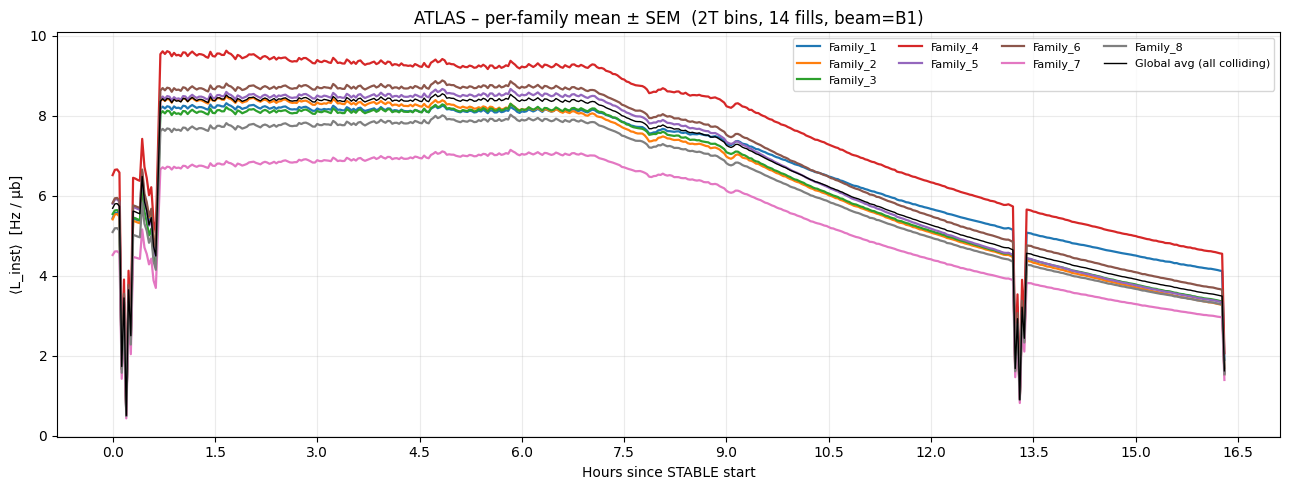

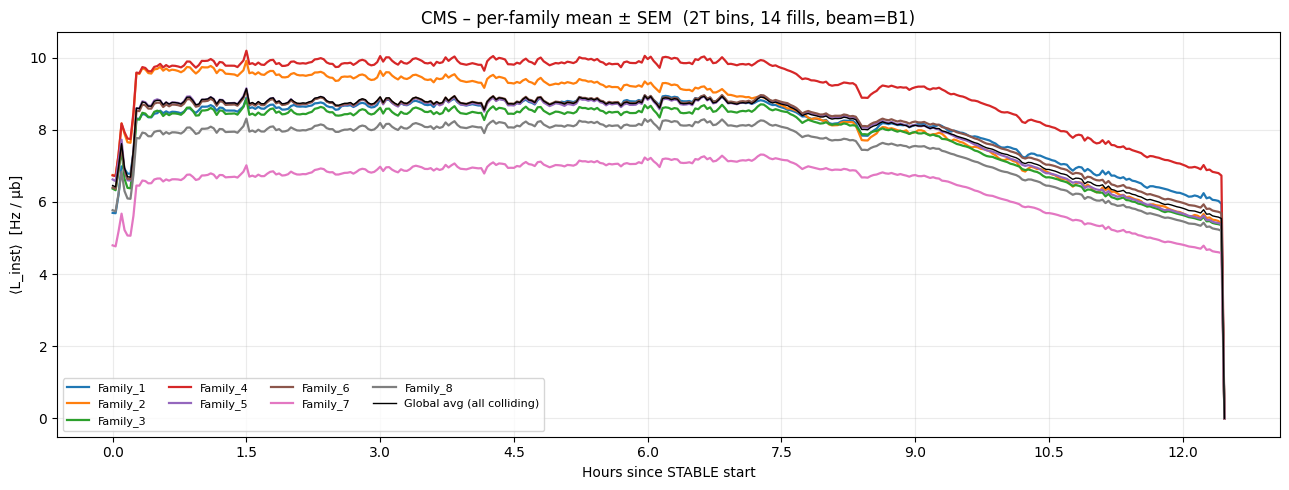

In [8]:
# ============================= configuration ===================================
from pathlib import Path
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# You already have these defined in your notebook/session:
# RAWDATA  = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/rawdata')
# FILLINFO = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/fills-info')
# fbmodes  = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
# beam, ip
# functions: build_families_for_fill(fillno, beam, ip, RAWDATA), LHCFillingPattern, load_series

# Force Path types (prevents "unsupported operand type(s) for /: 'str' and 'str'")
RAWDATA = Path(RAWDATA)
FILLINFO = Path(FILLINFO)

# Exactly your 14 fills:
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709])

RESAMPLE      = "2T"   # common grid step (e.g. "1T", "2T", "30S")
FAMILY_ORDER  = [f"Family_{k}" for k in range(1, 9)]
FAMILY_COLORS = {
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}
ATLAS_PV = "ATLAS:BUNCH_LUMI_INST"
CMS_PV   = "CMS:BUNCH_LUMI_INST"
_BMODE_PREF = ("STABLE", "ADJUST", "FLATTOP", "RAMP")

# ============================ filesystem helpers ================================
def _looks_like_fill_dir(p: Path, fno: int) -> bool:
    if not p.is_dir(): return False
    nm = p.name
    if f"HX:FILLN={fno}" in nm: return True
    return re.search(rf"(FILLN|fill|FILL)[^0-9]*{fno}(?!\d)", nm) is not None or nm == str(fno)

def _locate_fill_dir(root: Path, fno: int) -> Path | None:
    """Find directory that contains this fill. Checks root and one level below."""
    exact = root / f"HX:FILLN={fno}"
    if exact.is_dir():
        return exact
    for d in root.iterdir():
        if not d.is_dir(): 
            continue
        cand = d / f"HX:FILLN={fno}"
        if cand.is_dir():
            return cand
        if _looks_like_fill_dir(d, fno):
            return d
    return None

def _choose_bmode(fill_dir: Path) -> str | None:
    opts = [p for p in fill_dir.glob("HX:BMODE=*") if p.is_dir()]
    if not opts: return None
    names = {p.name.split("=", 1)[-1] for p in opts}
    for pref in _BMODE_PREF:
        if pref in names:
            return pref
    return sorted(names)[0]

# ===================== time window & per-fill accumulation ======================
def _stable_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    rows = (fbmodes.loc[fno]
                    .query("BMODE=='STABLE'")
                    .sort_values("tsStart"))
    if rows.empty:
        rows = fbmodes.loc[fno].sort_values("tsEnd").iloc[[-1]]
    return (pd.to_datetime(rows["tsStart"].iloc[0], utc=True),
            pd.to_datetime(rows["tsEnd"  ].iloc[0], utc=True))

def _colliding_slots_for_fill(fno: int, beam: str, dataroot: Path, bmode: str | None) -> np.ndarray:
    """Union of colliding slots for this fill via LHCFillingPattern."""
    try:
        if bmode:
            LHCFillingPattern.bmode = bmode
        fpat = LHCFillingPattern(fno, dataroot)  # pass Path, not str
    except Exception as e:
        print(f"[skip] fill {fno}: LHCFillingPattern failed ({e})")
        return np.array([], dtype=int)
    try:
        if beam.upper() == "B1":
            s15 = set(np.asarray(fpat.collbid_ip15["B1"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B1"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B1"], dtype=int))
        else:
            s15 = set(np.asarray(fpat.collbid_ip15["B2"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B2"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B2"], dtype=int))
        return np.array(sorted(s15 | s2 | s8), dtype=int)
    except Exception as e:
        print(f"[skip] fill {fno}: deriving colliding slots failed ({e})")
        return np.array([], dtype=int)

def _add_family_curves(ser_det: pd.Series,
                       M_det:   np.ndarray,
                       families: dict[str, np.ndarray],
                       t0_stb:  pd.Timestamp,
                       store   : dict[str, list[pd.Series]]) -> None:
    """Append per-family mean-over-slots time series to store[fam]."""
    td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
    for fam, slots in families.items():
        if not len(slots):
            continue
        slots = np.asarray(slots, dtype=int)
        curve = np.nanmean(M_det[:, slots], axis=1)           # mean over slots
        store.setdefault(fam, []).append(pd.Series(curve, index=td_index))

# ======================= per-fill collection (families + global) ================
def _collect_detector(det_pv: str, RAWDATA: Path, fills_exact: list[int]):
    RAWDATA = Path(RAWDATA)  # ensure Path
    fam_store: dict[str, list[pd.Series]] = {f: [] for f in FAMILY_ORDER}
    global_store: list[pd.Series] = []

    missing, used = [], []
    for fno in fills_exact:
        fdir = _locate_fill_dir(RAWDATA, int(fno))
        if fdir is None:
            print(f"[skip] fill {fno}: not found under RAWDATA")
            missing.append(fno)
            continue

        bmode = _choose_bmode(fdir)
        if not bmode:
            print(f"[skip] fill {fno}: no HX:BMODE=* under {fdir}")
            missing.append(fno)
            continue
        LHCFillingPattern.bmode = bmode

        # data_root is the parent that contains HX:FILLN=..., matching your other helpers
        data_root = fdir.parent if fdir.name.startswith("HX:FILLN=") else RAWDATA

        # STABLE window
        try:
            t0, t1 = _stable_window_utc(fno)
        except Exception as e:
            print(f"[skip] fill {fno}: STABLE window not found ({e})")
            missing.append(fno)
            continue

        # families for this fill (pass Path)
        try:
            families = build_families_for_fill(fillno=fno, beam=beam, ip=ip, RAWDATA=data_root)
        except Exception as e:
            print(f"[skip] fill {fno}: build_families_for_fill failed ({e})")
            missing.append(fno)
            continue

        # detector per-bunch series for this fill (pass Path)
        try:
            s = load_series(det_pv, data_root, fillno=fno)
        except Exception as e:
            print(f"[skip] fill {fno}: load_series failed for {det_pv} ({e})")
            missing.append(fno)
            continue

        s = s[(s.index >= t0) & (s.index <= t1)].dropna()
        if s.empty:
            print(f"[skip] fill {fno}: no {det_pv} data in STABLE window")
            missing.append(fno)
            continue

        try:
            M = np.stack(s.values)  # shape (n_times, 3564)
        except Exception as e:
            print(f"[skip] fill {fno}: stack detector array failed ({e})")
            missing.append(fno)
            continue

        # per-family curves for this fill
        _add_family_curves(s, M, families, t0, fam_store)

        # global (all colliding) curve for this fill
        slots_all = _colliding_slots_for_fill(fno, beam, data_root, bmode)
        if slots_all.size:
            curve_all = np.nanmean(M[:, slots_all], axis=1)
            td_index  = (s.index - t0).round("S")
            global_store.append(pd.Series(curve_all, index=td_index))

        used.append(fno)

    print(f"[info] requested fills: {list(fills_exact)}")
    print(f"[info] used {len(used)} fills: {used}")
    if missing:
        print(f"[warn] missing/failed {len(missing)} fills: {missing}")

    return fam_store, global_store

# ======================= collapse across fills to mean ± SEM ====================
def _mean_sem_from_list(series_list: list[pd.Series],
                        freq: str = RESAMPLE) -> tuple[pd.Series, pd.Series]:
    """Collapse a list of Timedelta-indexed Series to mean ± SEM on a common grid."""
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    start = min(s.index.min() for s in series_list)
    stop  = max(s.index.max() for s in series_list)
    grid  = pd.timedelta_range(start=start, end=stop, freq=freq)

    cols = []
    for s in series_list:
        sr = s.sort_index().resample(freq).mean().reindex(grid)
        cols.append(sr.rename(None))

    df = pd.concat(cols, axis=1)  # columns = fills
    mean = df.mean(axis=1, skipna=True)
    sem  = df.std(axis=1, ddof=1) / np.sqrt(df.count(axis=1).clip(lower=1))
    return mean, sem

def _collapse_series_list_to_mean(series_list: list[pd.Series]) -> pd.Series:
    m, _ = _mean_sem_from_list(series_list)
    return m

def _collapse_family_dict(family_dict: dict[str, list[pd.Series]]):
    """Return (mean_series_by_family, sem_by_family); one Series per family."""
    mean_by_fam, sem_by_fam = {}, {}
    for fam in FAMILY_ORDER:
        m, s = _mean_sem_from_list(family_dict.get(fam, []))
        mean_by_fam[fam] = m
        sem_by_fam[fam]  = s
    return mean_by_fam, sem_by_fam

# =============================== run the pipeline ===============================
atlas_fam_store, atlas_global_store = _collect_detector(ATLAS_PV, RAWDATA, fills.tolist())
cms_fam_store,   cms_global_store   = _collect_detector(CMS_PV, RAWDATA, fills.tolist())

curves_A, sems_A = _collapse_family_dict(atlas_fam_store)     # per-family mean ± SEM across fills
curves_C, sems_C = _collapse_family_dict(cms_fam_store)

global_A_mean = _collapse_series_list_to_mean(atlas_global_store)  # global mean across fills
global_C_mean = _collapse_series_list_to_mean(cms_global_store)

# ================================== plotting ===================================
def _plot_detector(det_name: str,
                   curves: dict[str, pd.Series],
                   sems:   dict[str, pd.Series],
                   global_mean: pd.Series,
                   ylab: str):
    plt.figure(figsize=(13, 5))
    plotted_any = False

    for k, fam in enumerate(FAMILY_ORDER):
        m = curves.get(fam, pd.Series(dtype=float))
        if m is None or m.empty:
            continue
        s   = sems.get(fam, pd.Series(dtype=float))
        col = FAMILY_COLORS.get(fam, plt.cm.tab10(k % 10))
        xh  = m.index.total_seconds() / 3600.0

        plt.plot(xh, m.values, lw=1.6, color=col, label=fam)
        plotted_any = True
        if s is not None and not s.empty:
            plt.fill_between(xh, (m - s).values, (m + s).values, color=col, alpha=.15, lw=0)

    if global_mean is not None and not global_mean.empty:
        gx = global_mean.index.total_seconds() / 3600.0
        plt.plot(gx, global_mean.values, 'k-', lw=1.0, label="Global avg (all colliding)")
        plotted_any = True

    ax = plt.gca()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    plt.xlabel("Hours since STABLE start")
    plt.ylabel(ylab)
    plt.title(f"{det_name} – per-family mean ± SEM  ({RESAMPLE} bins, {len(fills)} fills, beam={beam})")
    plt.grid(alpha=.25)
    if plotted_any:
        plt.legend(ncol=4, fontsize=8)
    else:
        print(f"[warn] {det_name}: nothing to plot (no valid fills after filtering)")
    plt.tight_layout()
    plt.show()

# ---- final figures
_ = _plot_detector("ATLAS", curves_A, sems_A, global_A_mean, "⟨L_inst⟩  [Hz / μb]")
_ = _plot_detector("CMS",   curves_C, sems_C, global_C_mean, "⟨L_inst⟩  [Hz / μb]")


/tmp/kpervain/ipykernel_2053390/2787358514.py:102: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2787358514.py:178: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2787358514.py:102: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2787358514.py:178: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2787358514.py:102: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).rou

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_2053390/2787358514.py:102: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2787358514.py:178: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2787358514.py:102: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
/tmp/kpervain/ipykernel_2053390/2787358514.py:178: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_2053390/2787358514.py:102: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).rou

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_2053390/2787358514.py:199: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_2053390/2787358514.py:203: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_2053390/2787358514.py:199: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_2053390/2787358514.py:203: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_2053390/2787358514.py:199: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  g

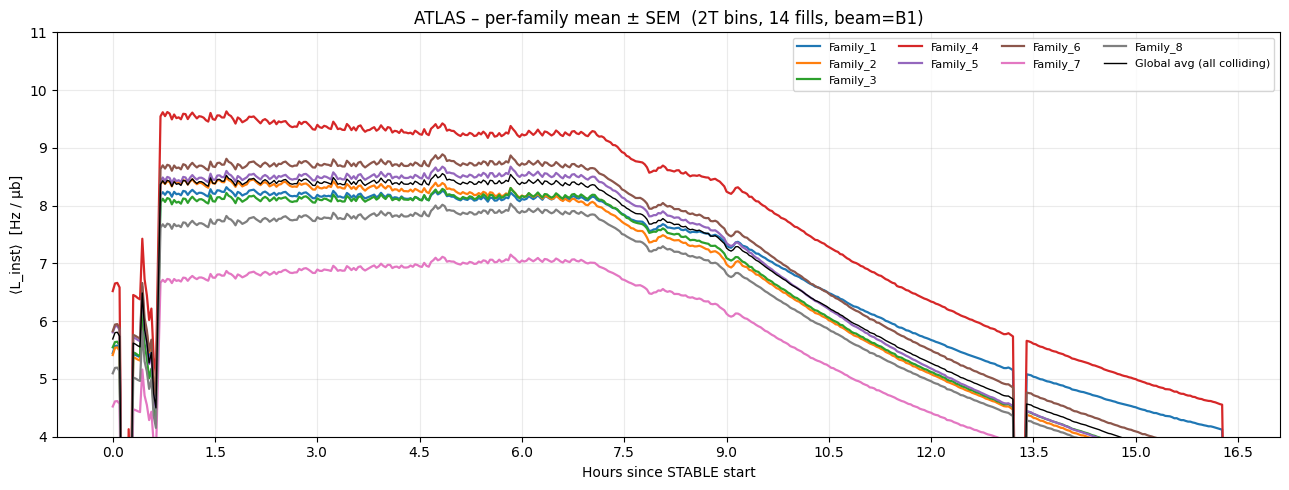

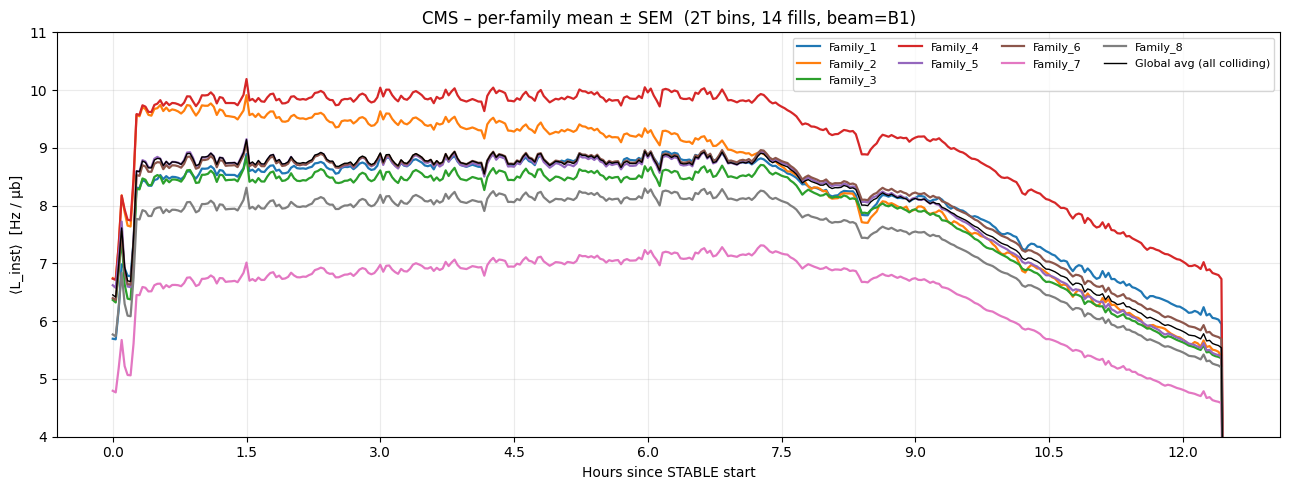

In [9]:
# ============================= configuration ===================================
from pathlib import Path
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# You already have these in your session; ensure they are Path objects:
# RAWDATA  = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/rawdata')
# FILLINFO = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/fills-info')
# fbmodes  = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
# beam, ip
# functions: build_families_for_fill(fillno, beam, ip, RAWDATA), LHCFillingPattern, load_series

RAWDATA  = Path(RAWDATA)
FILLINFO = Path(FILLINFO)

# Exactly your 14 fills:
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709])

RESAMPLE      = "2T"   # common grid step (e.g. "1T", "2T", "30S")
FAMILY_ORDER  = [f"Family_{k}" for k in range(1, 9)]
FAMILY_COLORS = {
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}
ATLAS_PV = "ATLAS:BUNCH_LUMI_INST"
CMS_PV   = "CMS:BUNCH_LUMI_INST"
_BMODE_PREF = ("STABLE", "ADJUST", "FLATTOP", "RAMP")

# ============================ filesystem helpers ================================
def _looks_like_fill_dir(p: Path, fno: int) -> bool:
    if not p.is_dir(): return False
    nm = p.name
    if f"HX:FILLN={fno}" in nm: return True
    return re.search(rf"(FILLN|fill|FILL)[^0-9]*{fno}(?!\d)", nm) is not None or nm == str(fno)

def _locate_fill_dir(root: Path, fno: int) -> Path | None:
    """Find directory that contains this fill. Checks root and one level below."""
    exact = root / f"HX:FILLN={fno}"
    if exact.is_dir():
        return exact
    for d in root.iterdir():
        if not d.is_dir():
            continue
        cand = d / f"HX:FILLN={fno}"
        if cand.is_dir():
            return cand
        if _looks_like_fill_dir(d, fno):
            return d
    return None

def _choose_bmode(fill_dir: Path) -> str | None:
    opts = [p for p in fill_dir.glob("HX:BMODE=*") if p.is_dir()]
    if not opts: return None
    names = {p.name.split("=", 1)[-1] for p in opts}
    for pref in _BMODE_PREF:
        if pref in names:
            return pref
    return sorted(names)[0]

# ===================== time window & per-fill accumulation ======================
def _stable_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    rows = (fbmodes.loc[fno]
                    .query("BMODE=='STABLE'")
                    .sort_values("tsStart"))
    if rows.empty:
        rows = fbmodes.loc[fno].sort_values("tsEnd").iloc[[-1]]
    return (pd.to_datetime(rows["tsStart"].iloc[0], utc=True),
            pd.to_datetime(rows["tsEnd"  ].iloc[0], utc=True))

def _colliding_slots_for_fill(fno: int, beam: str, dataroot: Path, bmode: str | None) -> np.ndarray:
    """Union of colliding slots for this fill via LHCFillingPattern."""
    try:
        if bmode:
            LHCFillingPattern.bmode = bmode
        fpat = LHCFillingPattern(fno, dataroot)  # pass Path, not str
    except Exception as e:
        print(f"[skip] fill {fno}: LHCFillingPattern failed ({e})")
        return np.array([], dtype=int)
    try:
        if beam.upper() == "B1":
            s15 = set(np.asarray(fpat.collbid_ip15["B1"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B1"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B1"], dtype=int))
        else:
            s15 = set(np.asarray(fpat.collbid_ip15["B2"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B2"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B2"], dtype=int))
        return np.array(sorted(s15 | s2 | s8), dtype=int)
    except Exception as e:
        print(f"[skip] fill {fno}: deriving colliding slots failed ({e})")
        return np.array([], dtype=int)

def _add_family_curves(ser_det: pd.Series,
                       M_det:   np.ndarray,
                       families: dict[str, np.ndarray],
                       t0_stb:  pd.Timestamp,
                       store   : dict[str, list[pd.Series]]) -> None:
    """Append per-family mean-over-slots time series to store[fam]."""
    td_index = (ser_det.index - t0_stb).round("S")  # TimedeltaIndex
    for fam, slots in families.items():
        if not len(slots):
            continue
        slots = np.asarray(slots, dtype=int)
        curve = np.nanmean(M_det[:, slots], axis=1)           # mean over slots
        store.setdefault(fam, []).append(pd.Series(curve, index=td_index))

# ======================= per-fill collection (families + global) ================
def _collect_detector(det_pv: str, RAWDATA: Path, fills_exact: list[int]):
    RAWDATA = Path(RAWDATA)  # ensure Path
    fam_store: dict[str, list[pd.Series]] = {f: [] for f in FAMILY_ORDER}
    global_store: list[pd.Series] = []

    missing, used = [], []
    for fno in fills_exact:
        fdir = _locate_fill_dir(RAWDATA, int(fno))
        if fdir is None:
            print(f"[skip] fill {fno}: not found under RAWDATA")
            missing.append(fno)
            continue

        bmode = _choose_bmode(fdir)
        if not bmode:
            print(f"[skip] fill {fno}: no HX:BMODE=* under {fdir}")
            missing.append(fno)
            continue
        LHCFillingPattern.bmode = bmode

        # data_root is the parent that contains HX:FILLN=..., matching your helpers
        data_root = fdir.parent if fdir.name.startswith("HX:FILLN=") else RAWDATA

        # STABLE window
        try:
            t0, t1 = _stable_window_utc(fno)
        except Exception as e:
            print(f"[skip] fill {fno}: STABLE window not found ({e})")
            missing.append(fno)
            continue

        # families for this fill (pass Path)
        try:
            families = build_families_for_fill(fillno=fno, beam=beam, ip=ip, RAWDATA=data_root)
        except Exception as e:
            print(f"[skip] fill {fno}: build_families_for_fill failed ({e})")
            missing.append(fno)
            continue

        # detector per-bunch series for this fill (pass Path)
        try:
            s = load_series(det_pv, data_root, fillno=fno)
        except Exception as e:
            print(f"[skip] fill {fno}: load_series failed for {det_pv} ({e})")
            missing.append(fno)
            continue

        s = s[(s.index >= t0) & (s.index <= t1)].dropna()
        if s.empty:
            print(f"[skip] fill {fno}: no {det_pv} data in STABLE window")
            missing.append(fno)
            continue

        try:
            M = np.stack(s.values)  # shape (n_times, 3564)
        except Exception as e:
            print(f"[skip] fill {fno}: stack detector array failed ({e})")
            missing.append(fno)
            continue

        # per-family curves for this fill
        _add_family_curves(s, M, families, t0, fam_store)

        # global (all colliding) curve for this fill
        slots_all = _colliding_slots_for_fill(fno, beam, data_root, bmode)
        if slots_all.size:
            curve_all = np.nanmean(M[:, slots_all], axis=1)
            td_index  = (s.index - t0).round("S")
            global_store.append(pd.Series(curve_all, index=td_index))

        used.append(fno)

    print(f"[info] requested fills: {list(fills_exact)}")
    print(f"[info] used {len(used)} fills: {used}")
    if missing:
        print(f"[warn] missing/failed {len(missing)} fills: {missing}")

    return fam_store, global_store

# ======================= collapse across fills to mean ± SEM ====================
def _mean_sem_from_list(series_list: list[pd.Series],
                        freq: str = RESAMPLE) -> tuple[pd.Series, pd.Series]:
    """Collapse a list of Timedelta-indexed Series to mean ± SEM on a common grid."""
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    start = min(s.index.min() for s in series_list)
    stop  = max(s.index.max() for s in series_list)
    grid  = pd.timedelta_range(start=start, end=stop, freq=freq)

    cols = []
    for s in series_list:
        sr = s.sort_index().resample(freq).mean().reindex(grid)
        cols.append(sr.rename(None))

    df = pd.concat(cols, axis=1)              # columns = fills
    mean = df.mean(axis=1, skipna=True)

    n = df.count(axis=1)
    std = df.std(axis=1, ddof=1)              # NaN when n<2
    sem = std / np.sqrt(n.where(n > 0, 1))    # avoid div by 0
    sem = sem.where(n >= 2, 0.0)              # if only 1 fill contributes → SEM=0

    return mean, sem

def _collapse_series_list_to_mean(series_list: list[pd.Series]) -> pd.Series:
    m, _ = _mean_sem_from_list(series_list)
    return m

def _collapse_family_dict(family_dict: dict[str, list[pd.Series]]):
    """Return (mean_series_by_family, sem_by_family); one Series per family."""
    mean_by_fam, sem_by_fam = {}, {}
    for fam in FAMILY_ORDER:
        m, s = _mean_sem_from_list(family_dict.get(fam, []))
        mean_by_fam[fam] = m
        sem_by_fam[fam]  = s
    return mean_by_fam, sem_by_fam

# =============================== run the pipeline ===============================
atlas_fam_store, atlas_global_store = _collect_detector(ATLAS_PV, RAWDATA, fills.tolist())
cms_fam_store,   cms_global_store   = _collect_detector(CMS_PV, RAWDATA, fills.tolist())

curves_A, sems_A = _collapse_family_dict(atlas_fam_store)     # per-family mean ± SEM across fills
curves_C, sems_C = _collapse_family_dict(cms_fam_store)

global_A_mean = _collapse_series_list_to_mean(atlas_global_store)  # global mean across fills
global_C_mean = _collapse_series_list_to_mean(cms_global_store)

# ================================== plotting ===================================
def _plot_detector(det_name: str,
                   curves: dict[str, pd.Series],
                   sems:   dict[str, pd.Series],
                   global_mean: pd.Series,
                   ylab: str):
    plt.figure(figsize=(13, 5))
    plotted_any = False

    for k, fam in enumerate(FAMILY_ORDER):
        m = curves.get(fam, pd.Series(dtype=float))
        if m is None or m.empty:
            continue
        s   = sems.get(fam, pd.Series(dtype=float))
        col = FAMILY_COLORS.get(fam, plt.cm.tab10(k % 10))
        xh  = m.index.total_seconds() / 3600.0

        plt.plot(xh, m.values, lw=1.6, color=col, label=fam)
        if s is not None and not s.empty:
            ylo = (m - s).values
            yhi = (m + s).values
            plt.fill_between(xh, ylo, yhi, color=col, alpha=.15, lw=0)

        plotted_any = True

    if global_mean is not None and not global_mean.empty:
        gx = global_mean.index.total_seconds() / 3600.0
        plt.plot(gx, global_mean.values, 'k-', lw=1.0, label="Global avg (all colliding)")
        plotted_any = True
        # If you also want SEM for global, compute it similarly and add another fill_between.

    ax = plt.gca()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    plt.ylim(4,11)
    plt.xlabel("Hours since STABLE start")
    plt.ylabel(ylab)
    plt.title(f"{det_name} – per-family mean ± SEM  ({RESAMPLE} bins, {len(fills)} fills, beam={beam})")
    plt.grid(alpha=.25)
    if plotted_any:
        plt.legend(ncol=4, fontsize=8)
    else:
        print(f"[warn] {det_name}: nothing to plot (no valid fills after filtering)")
    plt.tight_layout()
    plt.show()

# ---- final figures
_ = _plot_detector("ATLAS", curves_A, sems_A, global_A_mean, "⟨L_inst⟩  [Hz / μb]")
_ = _plot_detector("CMS",   curves_C, sems_C, global_C_mean, "⟨L_inst⟩  [Hz / μb]")


/tmp/kpervain/ipykernel_928158/845501847.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_928158/8455018

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_928158/845501847.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_928158/845501847.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_928158/8455018

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_928158/845501847.py:210: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_928158/845501847.py:214: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
/tmp/kpervain/ipykernel_928158/845501847.py:210: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_928158/845501847.py:214: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
/tmp/kpervain/ipykernel_928158/845501847.py:210: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' 

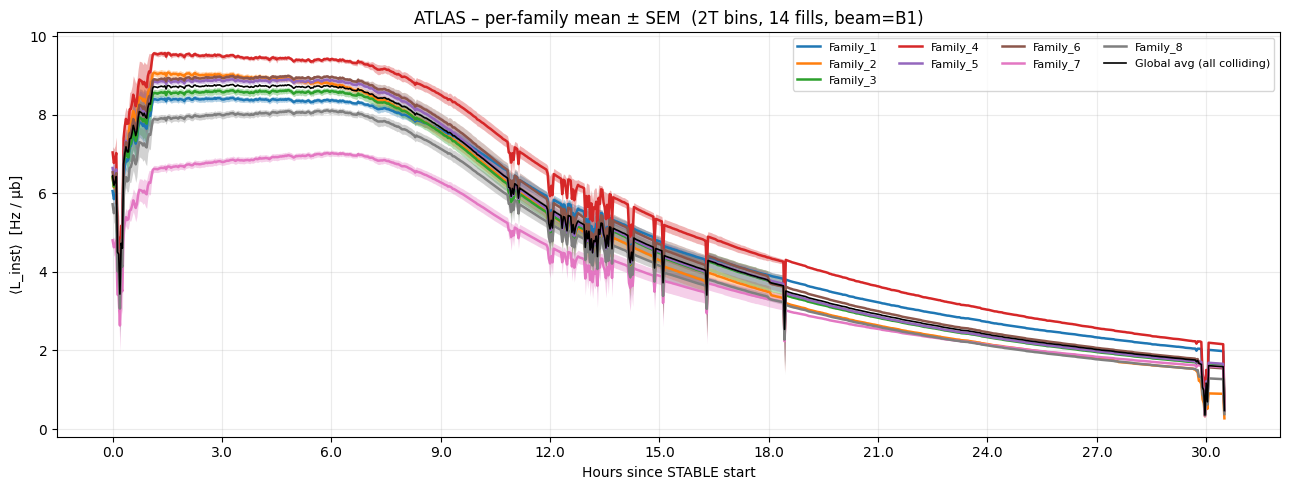

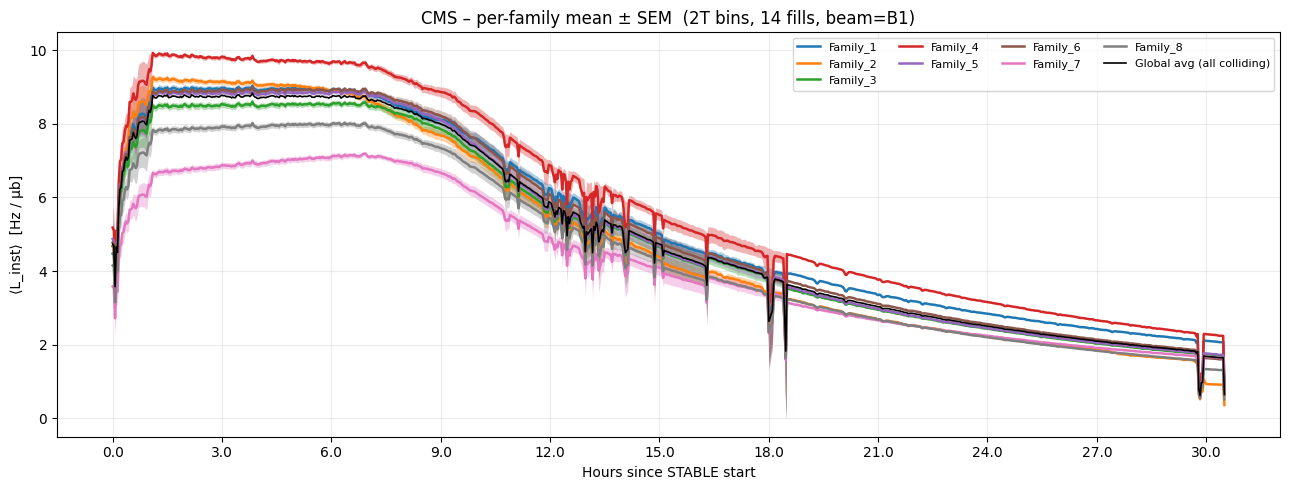

In [4]:
# ============================= configuration ===================================
from pathlib import Path
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure these exist in your session:
# RAWDATA  = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/rawdata')
# FILLINFO = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/fills-info')
# fbmodes  = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
# beam, ip
# functions: build_families_for_fill, LHCFillingPattern, load_series

RAWDATA  = Path(RAWDATA)
FILLINFO = Path(FILLINFO)

# Exactly your 14 fills:
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709])

RESAMPLE      = "2T"   # common grid step (e.g. "1T", "2T", "30S")
FAMILY_ORDER  = [f"Family_{k}" for k in range(1, 9)]
FAMILY_COLORS = {
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}
ATLAS_PV = "ATLAS:BUNCH_LUMI_INST"
CMS_PV   = "CMS:BUNCH_LUMI_INST"
_BMODE_PREF = ("STABLE", "ADJUST", "FLATTOP", "RAMP")

# ============================ filesystem helpers ================================
def _looks_like_fill_dir(p: Path, fno: int) -> bool:
    if not p.is_dir(): return False
    nm = p.name
    if f"HX:FILLN={fno}" in nm: return True
    return re.search(rf"(FILLN|fill|FILL)[^0-9]*{fno}(?!\d)", nm) is not None or nm == str(fno)

def _locate_fill_dir(root: Path, fno: int) -> Path | None:
    """Find directory that contains this fill. Checks root and one level below."""
    exact = root / f"HX:FILLN={fno}"
    if exact.is_dir():
        return exact
    for d in root.iterdir():
        if not d.is_dir(): 
            continue
        cand = d / f"HX:FILLN={fno}"
        if cand.is_dir():
            return cand
        if _looks_like_fill_dir(d, fno):
            return d
    return None

def _choose_bmode(fill_dir: Path) -> str | None:
    opts = [p for p in fill_dir.glob("HX:BMODE=*") if p.is_dir()]
    if not opts: return None
    names = {p.name.split("=", 1)[-1] for p in opts}
    for pref in _BMODE_PREF:
        if pref in names:
            return pref
    return sorted(names)[0]

# ===================== time window & per-fill accumulation ======================
def _stable_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    rows = (fbmodes.loc[fno]
                    .query("BMODE=='STABLE'")
                    .sort_values("tsStart"))
    if rows.empty:
        rows = fbmodes.loc[fno].sort_values("tsEnd").iloc[[-1]]
    return (pd.to_datetime(rows["tsStart"].iloc[0], utc=True),
            pd.to_datetime(rows["tsEnd"  ].iloc[0], utc=True))

def _colliding_slots_for_fill(fno: int, beam: str, dataroot: Path, bmode: str | None) -> np.ndarray:
    """Union of colliding slots for this fill via LHCFillingPattern."""
    try:
        if bmode:
            LHCFillingPattern.bmode = bmode
        fpat = LHCFillingPattern(fno, dataroot)  # pass Path
    except Exception as e:
        print(f"[skip] fill {fno}: LHCFillingPattern failed ({e})")
        return np.array([], dtype=int)
    try:
        if beam.upper() == "B1":
            s15 = set(np.asarray(fpat.collbid_ip15["B1"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B1"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B1"], dtype=int))
        else:
            s15 = set(np.asarray(fpat.collbid_ip15["B2"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B2"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B2"], dtype=int))
        return np.array(sorted(s15 | s2 | s8), dtype=int)
    except Exception as e:
        print(f"[skip] fill {fno}: deriving colliding slots failed ({e})")
        return np.array([], dtype=int)

def _add_family_curves(ser_det: pd.Series,
                       M_det:   np.ndarray,
                       families: dict[str, np.ndarray],
                       t0_stb:  pd.Timestamp,
                       store   : dict[str, list[pd.Series]]) -> None:
    """
    Append per-family mean-over-slots time series to store[fam].
    IMPORTANT: zero-align each fill so collapse grid lines up across fills.
    """
    # Timedelta since STABLE start, rounded to whole seconds
    td_index = (ser_det.index - t0_stb).round("S")
    # Force all fills to start exactly at 0
    td_index = td_index - td_index.min()

    for fam, slots in families.items():
        if not len(slots):
            continue
        slots = np.asarray(slots, dtype=int)
        curve = np.nanmean(M_det[:, slots], axis=1)
        store.setdefault(fam, []).append(pd.Series(curve, index=td_index))

# ======================= per-fill collection (families + global) ================
def _collect_detector(det_pv: str, RAWDATA: Path, fills_exact: list[int]):
    RAWDATA = Path(RAWDATA)  # ensure Path
    fam_store: dict[str, list[pd.Series]] = {f: [] for f in FAMILY_ORDER}
    global_store: list[pd.Series] = []

    missing, used = [], []
    for fno in fills_exact:
        fdir = _locate_fill_dir(RAWDATA, int(fno))
        if fdir is None:
            print(f"[skip] fill {fno}: not found under RAWDATA")
            missing.append(fno)
            continue

        bmode = _choose_bmode(fdir)
        if not bmode:
            print(f"[skip] fill {fno}: no HX:BMODE=* under {fdir}")
            missing.append(fno)
            continue
        LHCFillingPattern.bmode = bmode

        # data_root is the parent that contains HX:FILLN=...
        data_root = fdir.parent if fdir.name.startswith("HX:FILLN=") else RAWDATA

        # STABLE window
        try:
            t0, t1 = _stable_window_utc(fno)
        except Exception as e:
            print(f"[skip] fill {fno}: STABLE window not found ({e})")
            missing.append(fno)
            continue

        # families for this fill
        try:
            families = build_families_for_fill(fillno=fno, beam=beam, ip=ip, RAWDATA=data_root)
        except Exception as e:
            print(f"[skip] fill {fno}: build_families_for_fill failed ({e})")
            missing.append(fno)
            continue

        # detector per-bunch series for this fill
        try:
            s = load_series(det_pv, data_root, fillno=fno)
        except Exception as e:
            print(f"[skip] fill {fno}: load_series failed for {det_pv} ({e})")
            missing.append(fno)
            continue

        s = s[(s.index >= t0) & (s.index <= t1)].dropna()
        if s.empty:
            print(f"[skip] fill {fno}: no {det_pv} data in STABLE window")
            missing.append(fno)
            continue

        try:
            M = np.stack(s.values)  # shape (n_times, 3564)
        except Exception as e:
            print(f"[skip] fill {fno}: stack detector array failed ({e})")
            missing.append(fno)
            continue

        # per-family curves for this fill (zero-aligned)
        _add_family_curves(s, M, families, t0, fam_store)

        # global (all colliding) curve for this fill (also zero-aligned)
        slots_all = _colliding_slots_for_fill(fno, beam, data_root, bmode)
        if slots_all.size:
            curve_all = np.nanmean(M[:, slots_all], axis=1)
            td_index  = (s.index - t0).round("S")
            td_index  = td_index - td_index.min()
            global_store.append(pd.Series(curve_all, index=td_index))

        used.append(fno)

    print(f"[info] requested fills: {list(fills_exact)}")
    print(f"[info] used {len(used)} fills: {used}")
    if missing:
        print(f"[warn] missing/failed {len(missing)} fills: {missing}")

    return fam_store, global_store

# ======================= collapse across fills to mean ± SEM ====================
def _mean_sem_from_list(series_list: list[pd.Series],
                        freq: str = RESAMPLE) -> tuple[pd.Series, pd.Series]:
    """
    Collapse a list of Timedelta-indexed Series (already zero-aligned) to mean ± SEM
    on a common grid starting at 0.
    """
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    start = pd.Timedelta(0)
    stop  = max(s.index.max() for s in series_list)
    grid  = pd.timedelta_range(start=start, end=stop, freq=freq)

    cols = []
    for s in series_list:
        sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
        sr = sr.reindex(grid)                       # NaN where this fill has no data
        cols.append(sr.rename(None))

    df = pd.concat(cols, axis=1)                    # columns = fills
    mean = df.mean(axis=1, skipna=True)

    n   = df.count(axis=1)
    std = df.std(axis=1, ddof=1)                    # NaN when n<2
    sem = (std / np.sqrt(n.where(n > 0, 1))).where(n >= 2, 0.0)

    return mean, sem

def _collapse_series_list_to_mean(series_list: list[pd.Series]) -> pd.Series:
    m, _ = _mean_sem_from_list(series_list)
    return m

def _collapse_family_dict(family_dict: dict[str, list[pd.Series]]):
    """Return (mean_series_by_family, sem_by_family); one Series per family."""
    mean_by_fam, sem_by_fam = {}, {}
    for fam in FAMILY_ORDER:
        m, s = _mean_sem_from_list(family_dict.get(fam, []))
        mean_by_fam[fam] = m
        sem_by_fam[fam]  = s
    return mean_by_fam, sem_by_fam

# =============================== run the pipeline ===============================
atlas_fam_store, atlas_global_store = _collect_detector(ATLAS_PV, RAWDATA, fills.tolist())
cms_fam_store,   cms_global_store   = _collect_detector(CMS_PV, RAWDATA, fills.tolist())

curves_A, sems_A = _collapse_family_dict(atlas_fam_store)     # per-family mean ± SEM across fills
curves_C, sems_C = _collapse_family_dict(cms_fam_store)

global_A_mean = _collapse_series_list_to_mean(atlas_global_store)  # global mean across fills
global_C_mean = _collapse_series_list_to_mean(cms_global_store)

# ================================== plotting ===================================
def _plot_detector(det_name: str,
                   curves: dict[str, pd.Series],
                   sems:   dict[str, pd.Series],
                   global_mean: pd.Series,
                   ylab: str,
                   ylim: tuple[float, float] | None = None,
                   sem_alpha: float = 0.35):
    fig, ax = plt.subplots(figsize=(13, 5))
    plotted_any = False

    for k, fam in enumerate(FAMILY_ORDER):
        m = curves.get(fam, pd.Series(dtype=float))
        if m is None or m.empty:
            continue
        s = sems.get(fam, pd.Series(dtype=float))

        col = FAMILY_COLORS.get(fam, plt.cm.tab10(k % 10))
        xh  = (m.index.total_seconds() / 3600.0).astype(float)
        y   = m.to_numpy()

        # SEM band (mask NaNs)
        if s is not None and not s.empty:
            ylo = (m - s).to_numpy()
            yhi = (m + s).to_numpy()
            mask = np.isfinite(xh) & np.isfinite(ylo) & np.isfinite(yhi)
            if mask.any():
                ax.fill_between(xh[mask], ylo[mask], yhi[mask],
                                color=col, alpha=sem_alpha, lw=0, zorder=1)

        ax.plot(xh, y, lw=1.8, color=col, label=fam, zorder=2)
        plotted_any = True

    if global_mean is not None and not global_mean.empty:
        gx = (global_mean.index.total_seconds() / 3600.0).astype(float)
        gy = global_mean.to_numpy()
        ax.plot(gx, gy, 'k-', lw=1.2, label="Global avg (all colliding)", zorder=3)
        plotted_any = True

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.set_xlabel("Hours since STABLE start")
    ax.set_ylabel(ylab)
    ax.set_title(f"{det_name} – per-family mean ± SEM  ({RESAMPLE} bins, {len(fills)} fills, beam={beam})")
    ax.grid(alpha=.25)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if plotted_any:
        ax.legend(ncol=4, fontsize=8)
    fig.tight_layout()
    plt.show()

# ---- final figures (set ylim if you want)
_ = _plot_detector("ATLAS", curves_A, sems_A, global_A_mean, "⟨L_inst⟩  [Hz / μb]",
                   ylim=None, sem_alpha=0.35)
_ = _plot_detector("CMS",   curves_C, sems_C, global_C_mean, "⟨L_inst⟩  [Hz / μb]",
                   ylim=None, sem_alpha=0.35)


# Ips

In [8]:
# ================================================================
# CONFIG – tweak only the resampling step or colours if desired
# ================================================================
RESAMPLE = "2T"                              # common grid 2-min bins
IP_PANELS = ["15_only", "15_2", "15_8", "15_2_8"]   # four sub-plots
FAMILY_ORDER = [f"Family_{i}" for i in range(1,9)]

FAM_COL = {      # consistent colour palette
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}
DET_PVS  = {        # detector PVs → y-axis label
    "ATLAS" : ("ATLAS:BUNCH_LUMI_INST",   "⟨L_inst⟩  [Hz / μb]"),
    "CMS"   : ("CMS:BUNCH_LUMI_INST",     "⟨L_inst⟩  [Hz / μb]"),
}
INT_PVS  = {        # intensity PVs
    "Beam 1": ("LHC.BCTFR.B6R4.B1:BUNCH_INTENSITY", "⟨Intensity⟩  [p]"),
    "Beam 2": ("LHC.BCTFR.B6R4.B2:BUNCH_INTENSITY", "⟨Intensity⟩  [p]"),
}

# ================================================================
# A. helpers (tiny)
# ================================================================
def _stable_window_utc(fno:int):
    rows = (fbmodes.loc[fno]
                    .query("BMODE=='STABLE'")
                    .sort_values("tsStart"))
    if rows.empty:
        rows = fbmodes.loc[fno].sort_values("tsEnd").iloc[[-1]]
    return (pd.to_datetime(rows["tsStart"].iloc[0], utc=True),
            pd.to_datetime(rows["tsEnd"  ].iloc[0], utc=True))

def _add_curves(ser, M, fams, t0, ip_sets, store):
    """Fill store[ip_lbl][fam] → list[pd.Series] (index = TimedeltaIndex)"""
    td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
    for fam, slots in fams.items():
        if not len(slots):
            continue
        # classify these slots into the IP subsets --------------------------------
        part = _classify_slots_by_ip(slots, *ip_sets)        # <- helper from you
        for ip_lbl in IP_PANELS:
            use = part[ip_lbl]
            if not len(use):          # skip if family has no slot in this subset
                continue
            curve = np.nanmean(M[:, use], axis=1)            # mean over slots
            store.setdefault(ip_lbl, {}).setdefault(fam, []).append(
                pd.Series(curve, index=td_idx)
            )

def _mean_sem(series_list):
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    aligned = [s.resample(RESAMPLE).mean() for s in series_list]
    df = pd.concat(aligned, axis=1)
    return df.mean(axis=1), df.std(axis=1, ddof=1) / np.sqrt(df.count(axis=1))

def _aggregate(store):
    """store[ip_lbl][fam] -> (mean, sem)"""
    mean, sem = {}, {}
    for ip_lbl in IP_PANELS:
        ip_mean, ip_sem = {}, {}
        famdict = store.get(ip_lbl, {})
        for fam in FAMILY_ORDER:
            ip_mean[fam], ip_sem[fam] = _mean_sem(famdict.get(fam, []))
        mean[ip_lbl], sem[ip_lbl] = ip_mean, ip_sem
    return mean, sem

# ================================================================
# B.  collect all fills  → detector_store / intensity_store
# ================================================================
det_store  = {det:{} for det in DET_PVS}     # det_store[det][ip_lbl][fam] = list[Series]
int_store  = {b  :{} for b   in INT_PVS}

for fno in fills:
    try:
        t0, t1 = _stable_window_utc(fno)
    except Exception:
        continue
    # families (use global beam/ip variables you already defined)
    fams = build_families_for_fill(fno, beam=beam, ip=ip, RAWDATA=RAWDATA)
    # IP sets for classification
    sets = _ip_collision_sets_for_fill(fno, beam, RAWDATA)
    ip_sets = (sets["15"], sets["2"], sets["8"])

    # -- detectors (ATLAS / CMS) --------------------------------------
    for det, (pv, _) in DET_PVS.items():
        s = load_series(pv, RAWDATA, fno)
        s = s[(s.index>=t0) & (s.index<=t1)].dropna()
        if s.empty: continue
        _add_curves(s, np.stack(s.values), fams, t0, ip_sets, det_store[det])

    # -- intensities (B1 / B2) ---------------------------------------
    for bname, (pv, _) in INT_PVS.items():
        s = load_series(pv, RAWDATA, fno)
        s = s[(s.index>=t0) & (s.index<=t1)].dropna()
        if s.empty: continue
        _add_curves(s, np.stack(s.values), fams, t0, ip_sets, int_store[bname])


/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.


/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_idx = (ser.index - t0).round("S")          # TimedeltaIndex
/tmp/kpervain/ipykernel_1709679/3822383094.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.


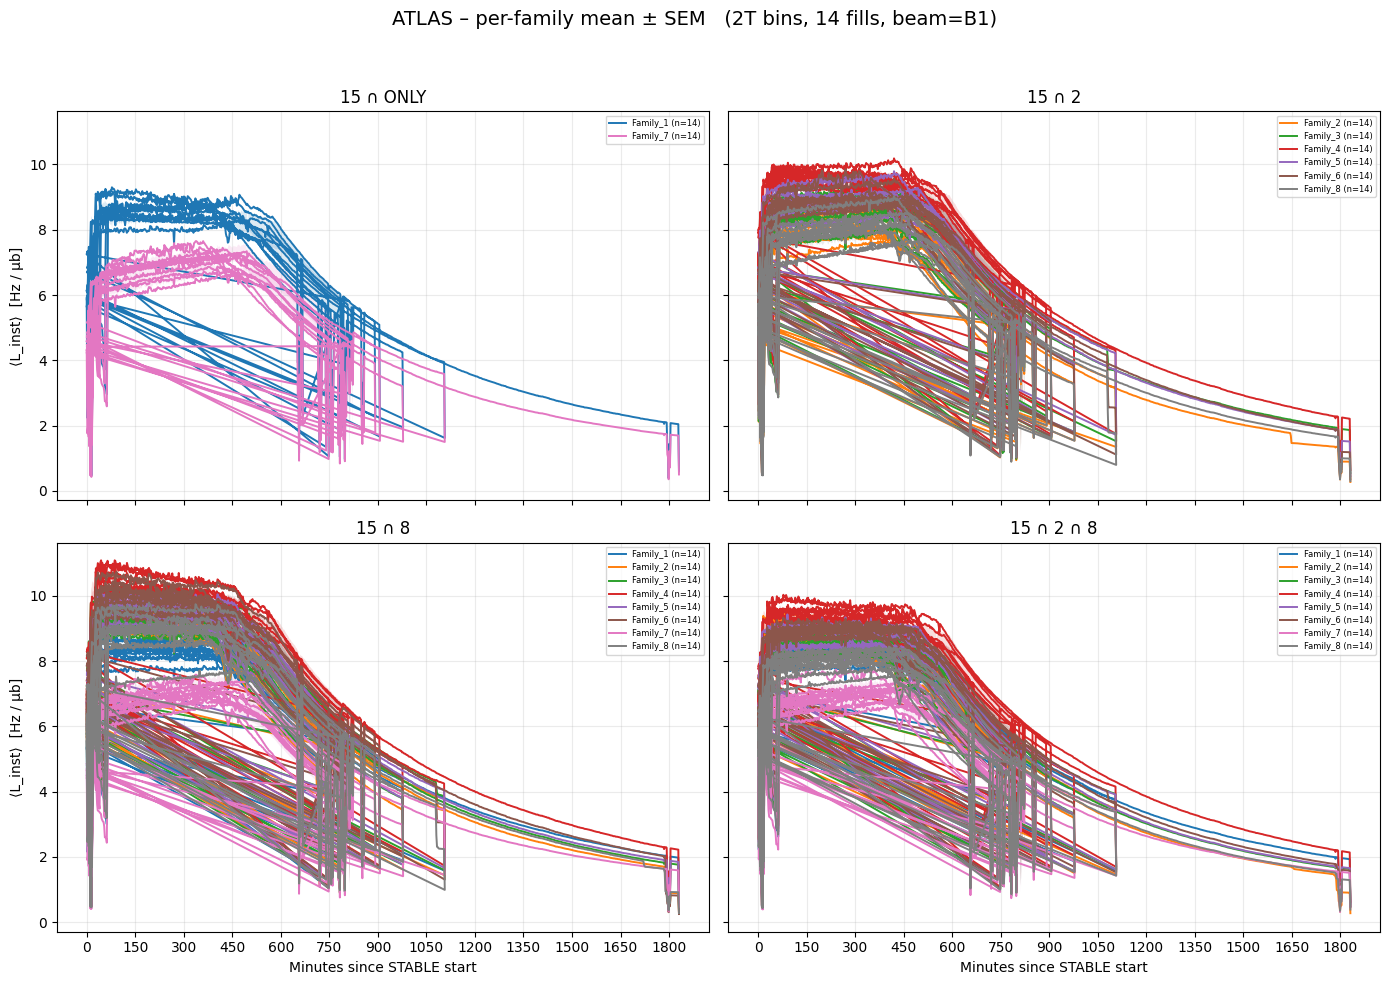

/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead

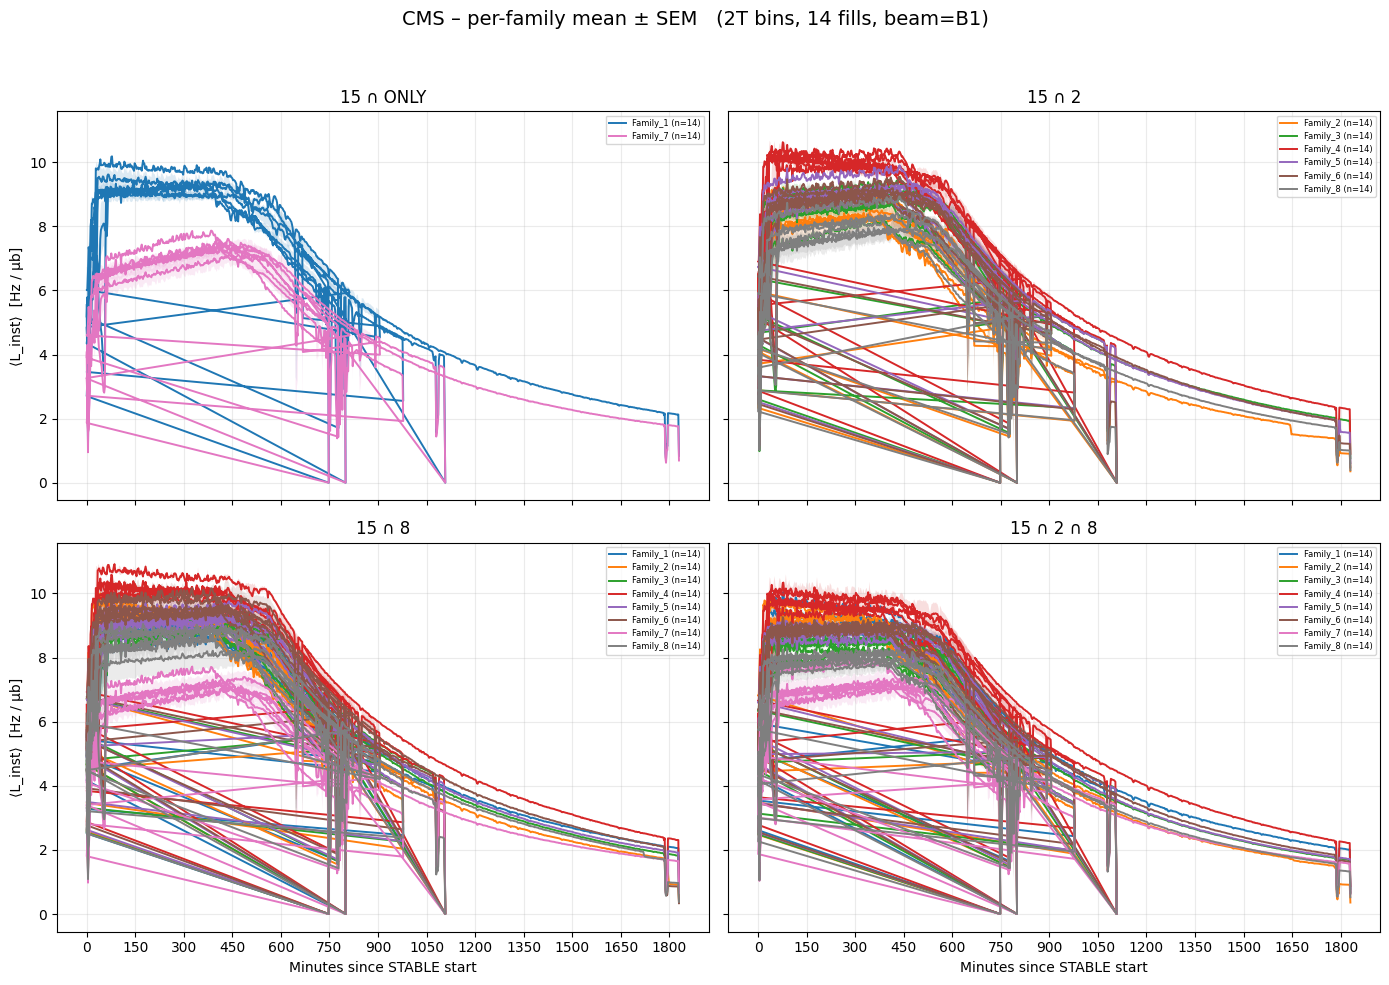

/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead

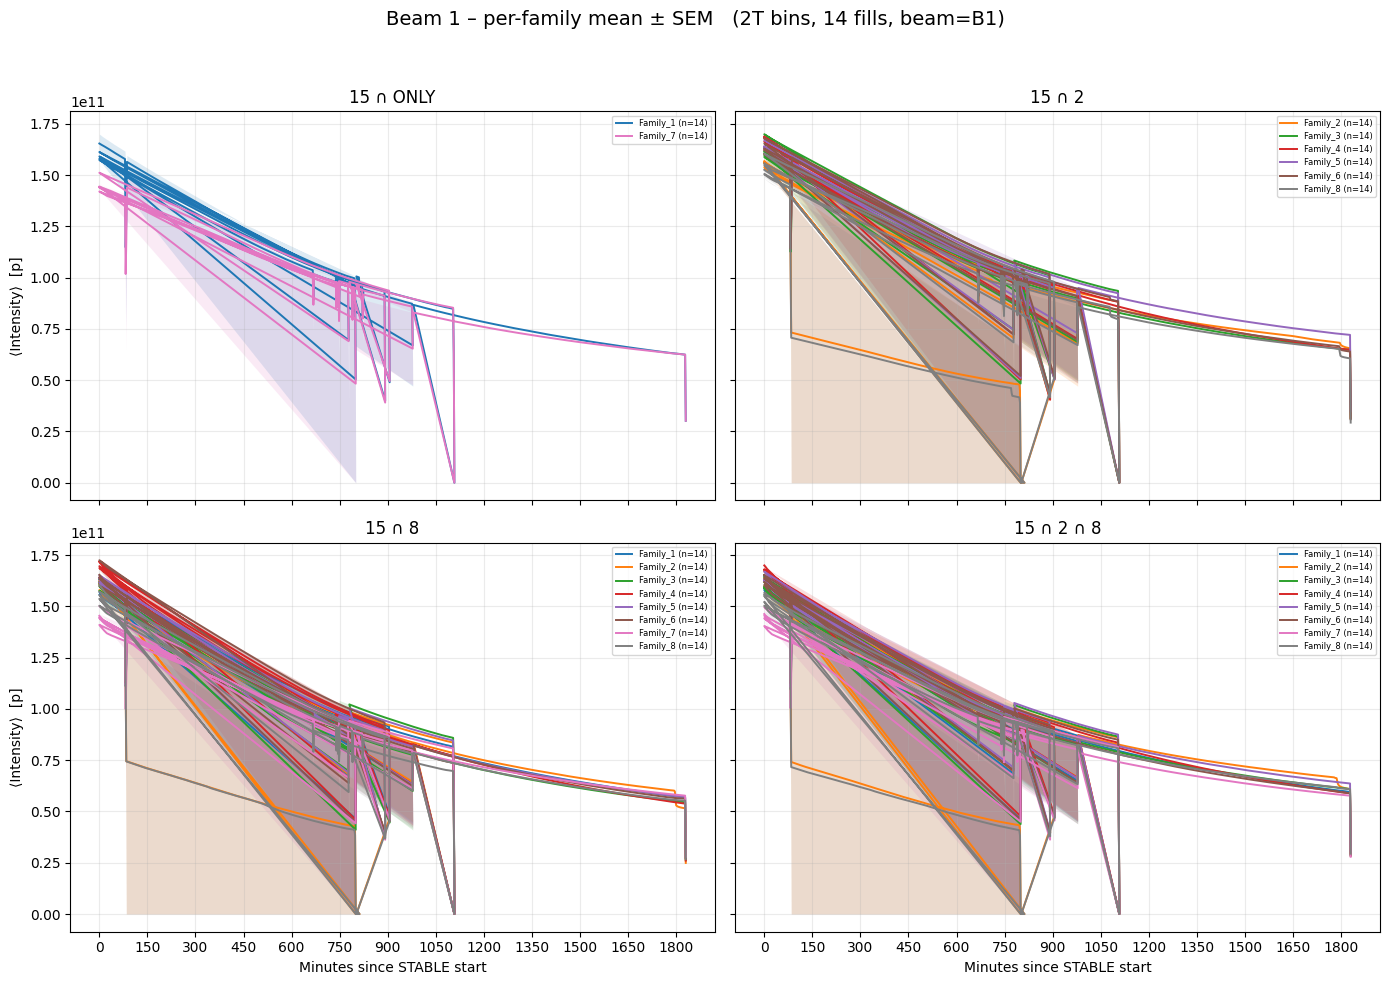

/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aligned = [s.resample(RESAMPLE).mean() for s in series_list]
/tmp/kpervain/ipykernel_1709679/3822383094.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead

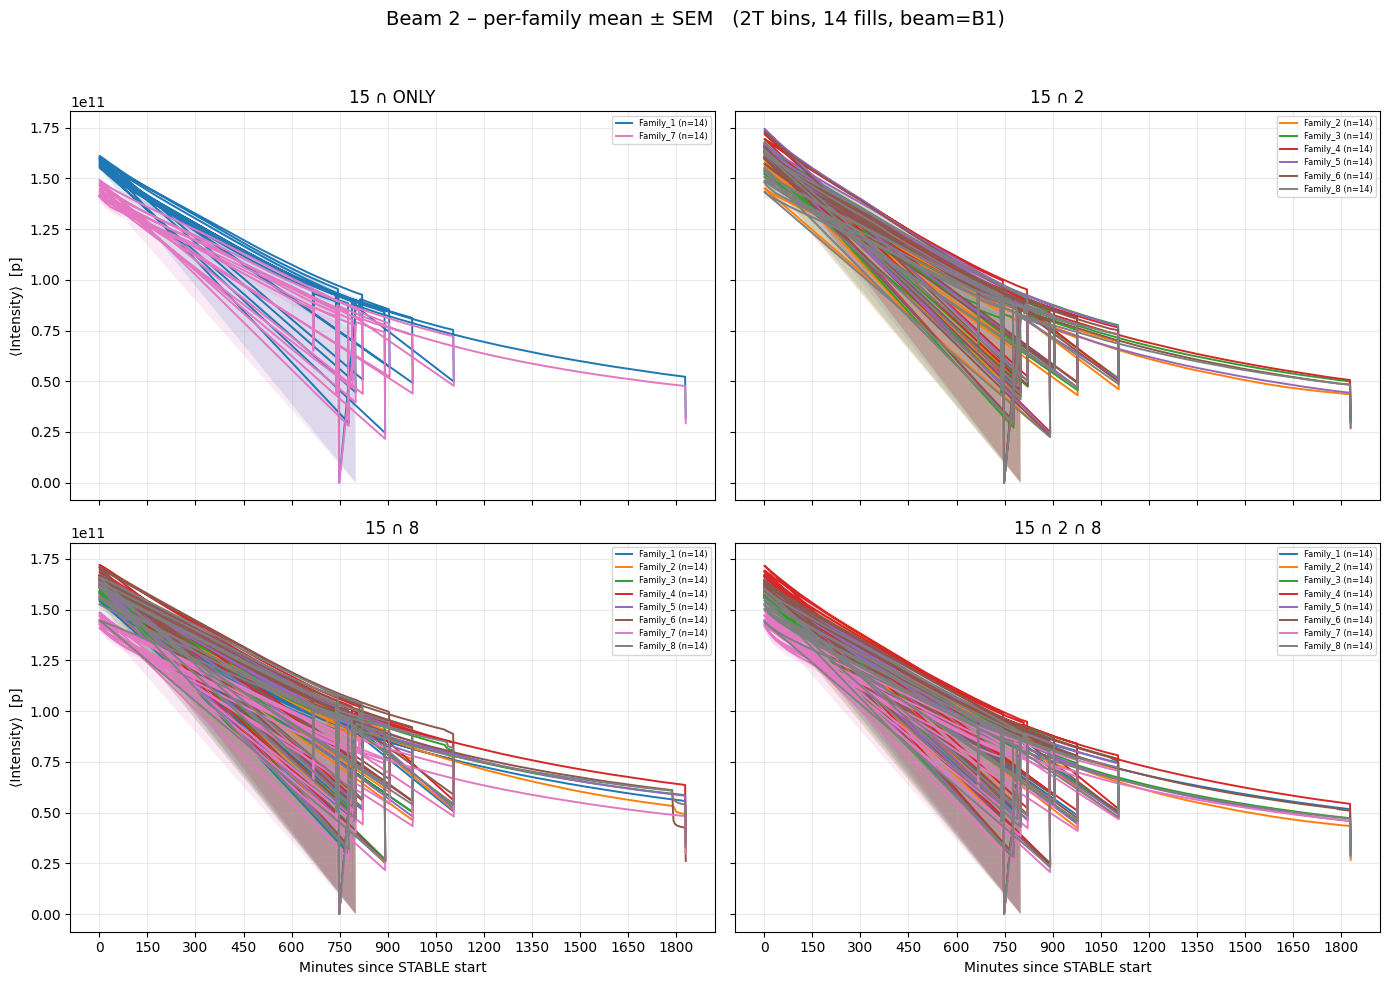

In [9]:

import matplotlib.dates as mdates
import matplotlib.ticker as mticker               # NEW – for MaxNLocator
# ──────────────────────────────────────────────────────────────────────
# A. Collect curves for all fills
# ──────────────────────────────────────────────────────────────────────
det_store = {d: {} for d in DET_PVS}
int_store = {b: {} for b in INT_PVS}

for fno in fills:
    try:
        t0, t1 = _stable_window_utc(fno)
    except Exception:
        continue

    fams = build_families_for_fill(fno, beam=beam, ip=ip, RAWDATA=RAWDATA)
    ip_sets = _ip_collision_sets_for_fill(fno, beam, RAWDATA)
    ip_tuple = (ip_sets["15"], ip_sets["2"], ip_sets["8"])

    # detectors -------------------------------------------------------
    for det, (pv, _) in DET_PVS.items():
        s = load_series(pv, RAWDATA, fno).loc[t0:t1].dropna()
        if s.empty: continue
        _add_curves(s, np.stack(s.values), fams, t0, ip_tuple, det_store[det])

    # intensities -----------------------------------------------------
    for bname, (pv, _) in INT_PVS.items():
        s = load_series(pv, RAWDATA, fno).loc[t0:t1].dropna()
        if s.empty: continue
        _add_curves(s, np.stack(s.values), fams, t0, ip_tuple, int_store[bname])

# ──────────────────────────────────────────────────────────────────────
# B. 4-panel plotting utility
# ──────────────────────────────────────────────────────────────────────
def _plot_four(title: str,
               ylab: str,
               mean: dict,
               sem: dict,
               raw_store: dict):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    axs = np.asarray(axs)                 # ensure array indexing
    pan_map = dict(zip(IP_PANELS, axs.flatten()))

    for ip_lbl, ax in pan_map.items():
        for k, fam in enumerate(FAMILY_ORDER):
            m = mean[ip_lbl][fam]
            if m.empty:
                continue
            s = sem[ip_lbl][fam]
            col = FAM_COL[fam]
            x = m.index.total_seconds() / 60.0
            ax.plot(x, m.values, lw=1.4, color=col,
                    label=f"{fam} (n={len(raw_store.get(ip_lbl, {}).get(fam, []))})")
            if not s.empty:
                ax.fill_between(x, m - s, m + s, color=col, alpha=0.15, lw=0)
        ax.set_title(ip_lbl.replace('_', ' ∩ ').upper())
        ax.grid(alpha=.25)
        ax.legend(fontsize=6)

        # keep axes readable – not more than ~20 major ticks
        ax.xaxis.set_major_locator(mticker.MaxNLocator(20, integer=True))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

    # labels
    for ax in axs[1, :]:
        ax.set_xlabel("Minutes since STABLE start")
    for ax in axs[:, 0]:
        ax.set_ylabel(ylab)

    fig.suptitle(f"{title} – per-family mean ± SEM   "
                 f"({RESAMPLE} bins, {len(fills)} fills, beam={beam})",
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# C.  Plot detectors
# ──────────────────────────────────────────────────────────────────────
for det, (_, ylab) in DET_PVS.items():
    mean, sem = _aggregate(det_store[det])
    _plot_four(det, ylab, mean, sem, det_store[det])

# ──────────────────────────────────────────────────────────────────────
# D.  Plot intensities
# ──────────────────────────────────────────────────────────────────────
for bname, (_, ylab) in INT_PVS.items():
    mean, sem = _aggregate(int_store[bname])
    _plot_four(bname, ylab, mean, sem, int_store[bname])
